# BIG DATA - E-COMMERCE PIPELINE

# SECTION 1: ENVIRONMENT SETUP

In [1]:
"""
This section installs and configures PySpark in Google Colab.
We also set up MongoDB connection and create necessary directories.
"""

# Install PySpark
!pip install pyspark --quiet

# Install MongoDB Spark Connector
# This allows PySpark to write directly to MongoDB
!pip install pymongo --quiet

# Import required libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
import os
from datetime import datetime



# Create Spark Session

In [2]:
"""
Initialize Spark with MongoDB configuration using environment variables.

"""

from google.colab import userdata

# Get MongoDB credentials from Colab secrets
MONGO_USERNAME = userdata.get('MONGO_USERNAME')
MONGO_PASSWORD = userdata.get('MONGO_PASSWORD')
MONGO_CLUSTER = userdata.get('MONGO_CLUSTER')
MONGO_DATABASE = userdata.get('MONGO_DATABASE')

# Build MongoDB connection URIs
MONGO_READ_URI = f"mongodb+srv://{MONGO_USERNAME}:{MONGO_PASSWORD}@{MONGO_CLUSTER}/{MONGO_DATABASE}?retryWrites=true&w=majority"
MONGO_WRITE_URI = f"mongodb+srv://{MONGO_USERNAME}:{MONGO_PASSWORD}@{MONGO_CLUSTER}/{MONGO_DATABASE}?retryWrites=true&w=majority"

# Initialize Spark with MongoDB Connector
spark = SparkSession.builder \
    .appName("ECommerce_Pipeline") \
    .config("spark.mongodb.read.connection.uri", MONGO_READ_URI) \
    .config("spark.mongodb.write.connection.uri", MONGO_WRITE_URI) \
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.1.1") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

print("Spark Session Created Successfully")
print(f"Spark Version: {spark.version}")
print(f"MongoDB Connector Configured")
print(f"Database: {MONGO_DATABASE}")



Spark Session Created Successfully
Spark Version: 4.0.4
MongoDB Connector Configured
Database: bigdata_ecommerce_db


# MongoDB Credentials Setup

In [3]:
# Build connection string from environment variables
from google.colab import userdata
MONGO_USERNAME=userdata.get('MONGO_USERNAME')
MONGO_PASSWORD=userdata.get('MONGO_PASSWORD')
MONGO_CLUSTER=userdata.get('MONGO_CLUSTER')
MONGO_DATABASE=userdata.get('MONGO_DATABASE')
MONGO_URI = f"mongodb+srv://{MONGO_USERNAME}:{MONGO_PASSWORD}@{MONGO_CLUSTER}/{MONGO_DATABASE}"

print("MongoDB credentials configured")

MongoDB credentials configured


# Create Directory Structure

In [4]:
"""
Load the e-commerce dataset from Google Drive.
First we need to mount Google Drive to access the file.
"""

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully


In [5]:
"""
Create folders to store Bronze, Silver, and Gold layer data.
This keeps our data organized by processing stage.
"""

# Set base path to Google Drive
DRIVE_BASE_PATH = "/content/drive/MyDrive/Big data"

# Create main directories in Google Drive
import os
directories = [
    f'{DRIVE_BASE_PATH}/bronze_layer',
    f'{DRIVE_BASE_PATH}/silver_layer',
    f'{DRIVE_BASE_PATH}/gold_layer',
    f'{DRIVE_BASE_PATH}/reports',
    f'{DRIVE_BASE_PATH}/micro_batch/bronze',
    f'{DRIVE_BASE_PATH}/micro_batch/silver',
    f'{DRIVE_BASE_PATH}/micro_batch/gold',
    f'{DRIVE_BASE_PATH}/micro_batch/logs'
]

for directory in directories:
    if not os.path.exists(directory):
        os.makedirs(directory)

# SECTION 2: BRONZE LAYER - RAW DATA INGESTION

# Load Dataset

In [6]:
file_path = "/content/drive/MyDrive/Big data/online_retail.csv"


# Read CSV file into Spark DataFrame
# inferSchema=True lets Spark automatically detect data types
df_raw = spark.read.csv(
    file_path,
    header=True,
    inferSchema=True
)

print("Dataset loaded successfully from Google Drive")
print(f"Total records: {df_raw.count():,}")

Dataset loaded successfully from Google Drive
Total records: 541,910


# Inspect Raw Data

In [7]:
"""
Check the schema and preview the data to understand what we are working with.
"""

# Display schema
print("\n=== Dataset Schema ===")
df_raw.printSchema()

# Show sample records
print("\n=== Sample Records ===")
df_raw.show(5, truncate=False)

# Check column names
print("\n=== Column Names ===")
print(df_raw.columns)

# Get record count
total_records = df_raw.count()
print(f"\n=== Total Records: {total_records:,} ===")



=== Dataset Schema ===
root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- Price: double (nullable = true)
 |-- Customer ID: integer (nullable = true)
 |-- Country: string (nullable = true)


=== Sample Records ===
+-------+---------+-----------------------------------+--------+------------+-----+-----------+--------------+
|Invoice|StockCode|Description                        |Quantity|InvoiceDate |Price|Customer ID|Country       |
+-------+---------+-----------------------------------+--------+------------+-----+-----------+--------------+
|536365 |85123A   |WHITE HANGING HEART T-LIGHT HOLDER |6       |12/1/10 8:26|2.55 |17850      |United Kingdom|
|536365 |71053    |WHITE METAL LANTERN                |6       |12/1/10 8:26|3.39 |17850      |United Kingdom|
|536365 |84406B   |CREAM CUPID HEARTS COAT HANGER     |8       |

# Data Type Corrections

In [8]:
"""
Fix data types for proper processing.
The main issue is InvoiceDate which needs to be converted to timestamp.
Customer ID should be integer but has nulls so we keep as double for now.
"""

# Convert InvoiceDate from string to timestamp

df_bronze = df_raw.withColumn(
    "InvoiceDate",
    to_timestamp(col("InvoiceDate"), "M/d/yy H:mm")
)

print("\n=== Bronze Layer Schema (After Type Conversion) ===")
df_bronze.printSchema()

# Verify the date conversion worked
print("\n=== Sample Records with Converted Date ===")
df_bronze.select("Invoice", "InvoiceDate", "Customer ID", "Country").show(5, truncate=False)

# Check for null dates which indicates conversion failed
null_dates = df_bronze.filter(col("InvoiceDate").isNull()).count()

print(f"\nNull InvoiceDate records: {null_dates}")
if null_dates > 0:
    print(" failed to convert")



=== Bronze Layer Schema (After Type Conversion) ===
root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Price: double (nullable = true)
 |-- Customer ID: integer (nullable = true)
 |-- Country: string (nullable = true)


=== Sample Records with Converted Date ===
+-------+-------------------+-----------+--------------+
|Invoice|InvoiceDate        |Customer ID|Country       |
+-------+-------------------+-----------+--------------+
|536365 |2010-12-01 08:26:00|17850      |United Kingdom|
|536365 |2010-12-01 08:26:00|17850      |United Kingdom|
|536365 |2010-12-01 08:26:00|17850      |United Kingdom|
|536365 |2010-12-01 08:26:00|17850      |United Kingdom|
|536365 |2010-12-01 08:26:00|17850      |United Kingdom|
+-------+-------------------+-----------+--------------+
only showing top 5 rows

Null InvoiceDate records: 0


# Add Partitioning Columns

In [9]:
"""
Add year and month columns for partitioning.
Partitioning improves query performance when filtering by date.
"""

# Extract year and month from InvoiceDate
df_bronze = df_bronze.withColumn("Year", year(col("InvoiceDate"))) \
                     .withColumn("Month", month(col("InvoiceDate")))

print("\n=== Bronze Layer with Partitioning Columns ===")
df_bronze.select("Invoice", "InvoiceDate", "Year", "Month").show(5)

# Check the date range in our data
print("\n=== Date Range in Dataset ===")
df_bronze.select(
    min("InvoiceDate").alias("Earliest_Date"),
    max("InvoiceDate").alias("Latest_Date")
).show(truncate=False)

# Check how many records per year-month
print("\n=== Records per Year-Month ===")
df_bronze.groupBy("Year", "Month") \
    .agg(count("*").alias("Record_Count")) \
    .orderBy("Year", "Month") \
    .show()



=== Bronze Layer with Partitioning Columns ===
+-------+-------------------+----+-----+
|Invoice|        InvoiceDate|Year|Month|
+-------+-------------------+----+-----+
| 536365|2010-12-01 08:26:00|2010|   12|
| 536365|2010-12-01 08:26:00|2010|   12|
| 536365|2010-12-01 08:26:00|2010|   12|
| 536365|2010-12-01 08:26:00|2010|   12|
| 536365|2010-12-01 08:26:00|2010|   12|
+-------+-------------------+----+-----+
only showing top 5 rows

=== Date Range in Dataset ===
+-------------------+-------------------+
|Earliest_Date      |Latest_Date        |
+-------------------+-------------------+
|2010-12-01 08:26:00|2011-12-09 12:50:00|
+-------------------+-------------------+


=== Records per Year-Month ===
+----+-----+------------+
|Year|Month|Record_Count|
+----+-----+------------+
|2010|   12|       42481|
|2011|    1|       35147|
|2011|    2|       27707|
|2011|    3|       36748|
|2011|    4|       29916|
|2011|    5|       37030|
|2011|    6|       36874|
|2011|    7|       39518|

# Save Bronze Layer as Partitioned Parquet

In [10]:
"""
Save the data as Parquet format with partitioning.
Parquet is a columnar storage format that compresses well.
Partitioning by year and month makes queries faster.
"""

bronze_path = f"{DRIVE_BASE_PATH}/bronze_layer/ecommerce_data"

# Write as parquet with partitioning
df_bronze.write \
    .mode("overwrite") \
    .partitionBy("Year", "Month") \
    .parquet(bronze_path)

print(f"\n=== Bronze Layer Saved to: {bronze_path} ===")

# List the created partition folders
print("\n=== Partition Folders Created ===")
!!ls -lh /content/drive/MyDrive/Big\ data/bronze_layer/ecommerce_data/



=== Bronze Layer Saved to: /content/drive/MyDrive/Big data/bronze_layer/ecommerce_data ===

=== Partition Folders Created ===


['total 8.0K',
 '-rw-------  1 root root    0 Aug 30 14:46  _SUCCESS',
 "drwx------  3 root root 4.0K Aug 30 14:46 'Year=2010'",
 "drwx------ 14 root root 4.0K Aug 30 14:46 'Year=2011'"]

# Verify Bronze Layer

In [11]:
"""
Read back the saved data to verify it was saved correctly.
"""

# Read the parquet file back
df_bronze_verify = spark.read.parquet(bronze_path)

print("\n=== Bronze Layer Verification ===")
print(f"Original count: {df_bronze.count():,}")
print(f"Saved count: {df_bronze_verify.count():,}")

# Show sample from saved data
df_bronze_verify.show(5)

# Check schema is preserved
print("\n=== Verified Schema ===")
df_bronze_verify.printSchema()


=== Bronze Layer Verification ===
Original count: 541,910
Saved count: 541,910
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+----+-----+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|       Country|Year|Month|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+----+-----+
| 573744|    21314|SMALL GLASS HEART...|       8|2011-11-01 08:16:00|  2.1|      17733|United Kingdom|2011|   11|
| 573744|    21704|BAG 250g SWIRLY M...|      12|2011-11-01 08:16:00| 0.85|      17733|United Kingdom|2011|   11|
| 573744|    21791|VINTAGE HEADS AND...|      12|2011-11-01 08:16:00| 1.25|      17733|United Kingdom|2011|   11|
| 573744|    21892|TRADITIONAL WOODE...|      12|2011-11-01 08:16:00| 1.25|      17733|United Kingdom|2011|   11|
| 573744|    21915|RED  HARMONICA IN...|      12|2011-11-01 08:16:00| 1.25|      17733|United Kingdom|2011|   11|
+-------

# Bronze Layer Summary Statistics

In [12]:
"""
Generate summary statistics for the Bronze layer.
This helps us understand the data before cleaning.
"""

print("\n=== BRONZE LAYER SUMMARY ===")
print(f"Total Records: {df_bronze.count():,}")
print(f"Total Columns: {len(df_bronze.columns)}")
print(f"Date Range: {df_bronze.select(min('InvoiceDate')).first()[0]} to {df_bronze.select(max('InvoiceDate')).first()[0]}")

# Count records by country
print("\n=== Top 10 Countries by Transaction Count ===")
df_bronze.groupBy("Country") \
    .agg(count("*").alias("Transaction_Count")) \
    .orderBy(desc("Transaction_Count")) \
    .show(10)

# Count unique values
print("\n=== Unique Value Counts ===")
print(f"Unique Invoices: {df_bronze.select('Invoice').distinct().count():,}")
print(f"Unique Products: {df_bronze.select('StockCode').distinct().count():,}")
print(f"Unique Customers: {df_bronze.select('Customer ID').distinct().count():,}")



=== BRONZE LAYER SUMMARY ===
Total Records: 541,910
Total Columns: 10
Date Range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00

=== Top 10 Countries by Transaction Count ===
+--------------+-----------------+
|       Country|Transaction_Count|
+--------------+-----------------+
|United Kingdom|           495478|
|       Germany|             9495|
|        France|             8558|
|          EIRE|             8196|
|         Spain|             2533|
|   Netherlands|             2371|
|       Belgium|             2069|
|   Switzerland|             2002|
|      Portugal|             1519|
|     Australia|             1259|
+--------------+-----------------+
only showing top 10 rows

=== Unique Value Counts ===
Unique Invoices: 25,900
Unique Products: 4,070
Unique Customers: 4,373


FIGURE 2: GEOGRAPHIC DISTRIBUTION OF TRANSACTIONS


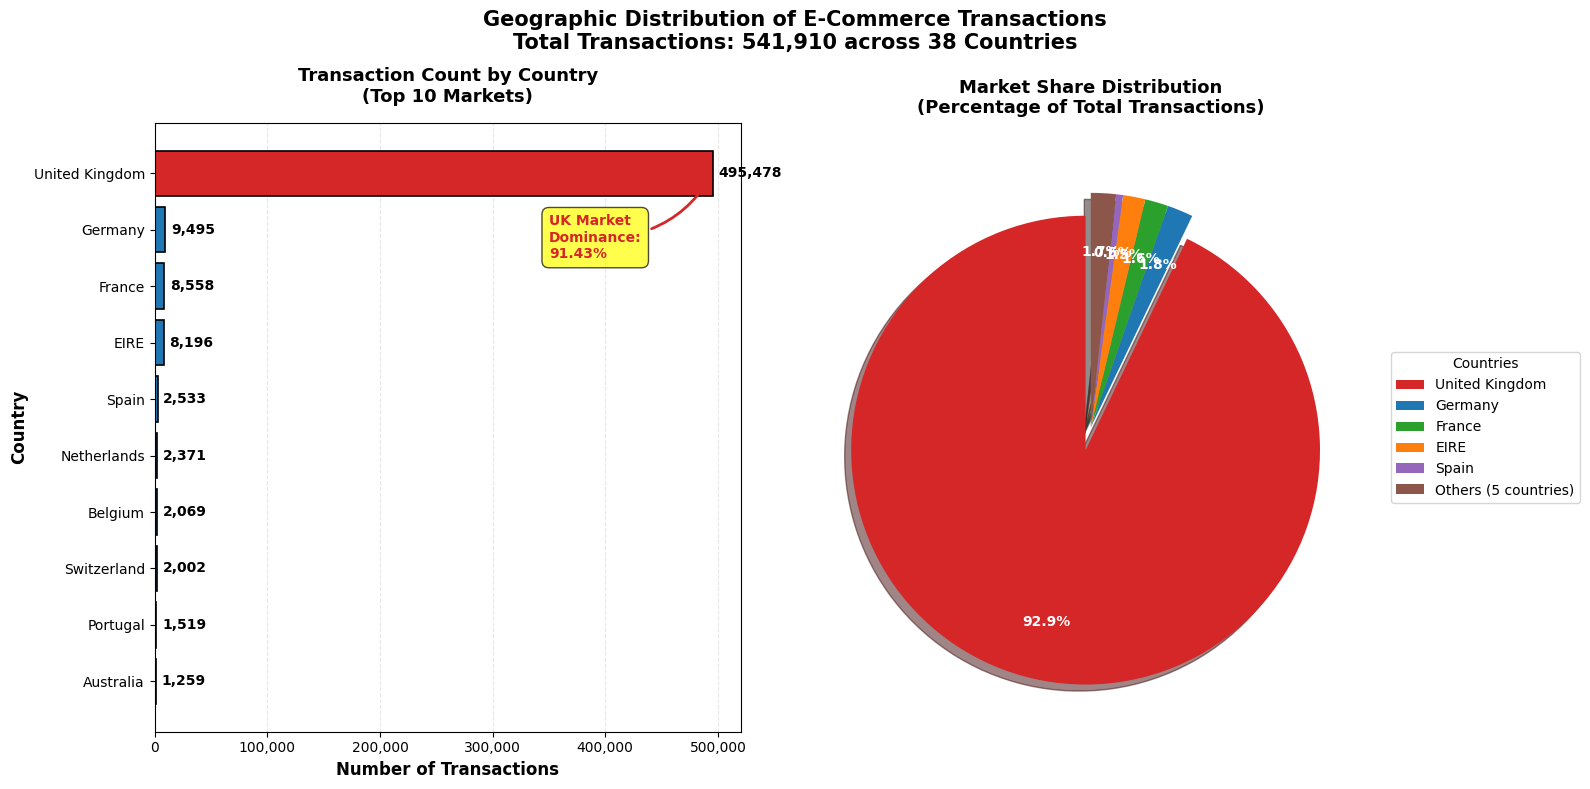

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def create_geographic_distribution_chart(df_bronze):
    """Create geographic distribution bar chart"""


    # Get top 10 countries Dynamically from Spark DataFrame
    total_count = df_bronze.count()

    top10_spark_df = df_bronze.groupBy("Country") \
        .agg(count("*").alias("Transactions")) \
        .orderBy(desc("Transactions")) \
        .limit(10)

    # Convert Spark DataFrame to Pandas DataFrame
    df = top10_spark_df.toPandas()

    # Calculate precentage Dynamically
    df['Percentage'] = (df['Transactions'] / total_count) * 100


    #.........................................................

    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))


    # Color UK differently to highlight dominance
    colors = ['#1f77b4' if country != 'United Kingdom' else '#d62728'
              for country in df['Country']]

    bars1 = ax1.barh(df['Country'], df['Transactions'], color=colors,
                     edgecolor='black', linewidth=1.2)

    # Add value labels
    for i, (country, trans) in enumerate(zip(df['Country'], df['Transactions'])):
        ax1.text(trans + 5000, i, f'{trans:,}',
                va='center', fontsize=10, fontweight='bold')

    ax1.set_xlabel('Number of Transactions', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Country', fontsize=12, fontweight='bold')
    ax1.set_title('Transaction Count by Country\n(Top 10 Markets)',
                 fontsize=13, fontweight='bold', pad=15)
    ax1.grid(axis='x', alpha=0.3, linestyle='--')
    ax1.set_axisbelow(True)

    # Format x-axis with commas
    ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

    # Invert y-axis to have UK at top
    ax1.invert_yaxis()

    # Add UK dominance annotation
    ax1.annotate('UK Market\nDominance:\n91.43%',
                xy=(495478, 0),
                xytext=(350000, 1.5),
                fontsize=10,
                fontweight='bold',
                color='#d62728',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3',
                              color='#d62728', lw=2))

    # ===== RIGHT CHART: Percentage Distribution =====
    # Pie chart for better percentage visualization
    colors_pie = ['#d62728' if country == 'United Kingdom' else '#1f77b4'
                  for country in df['Country']]

    # Only show top 5 + "Others" for cleaner pie chart
    top5 = df.head(5).copy()
    others_pct = df['Percentage'][5:].sum()
    others_trans = df['Transactions'][5:].sum()

    pie_data = pd.concat([
        top5,
        pd.DataFrame({'Country': ['Others (5 countries)'],
                     'Transactions': [others_trans],
                     'Percentage': [others_pct]})
    ])

    colors_pie = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd', '#8c564b']

    wedges, texts, autotexts = ax2.pie(pie_data['Percentage'],
                                        autopct='%1.1f%%',
                                        colors=colors_pie,
                                        startangle=90,
                                        explode=[0.1, 0, 0, 0, 0, 0],
                                        shadow=True,
                                        pctdistance=0.75)

    # ADD the legand
    ax2.legend(wedges, pie_data['Country'], title="Countries", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

    # Bold the percentages
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(10)

    # Bold the labels
    for text in texts:
        text.set_fontweight('bold')
        text.set_fontsize(10)

    ax2.set_title('Market Share Distribution\n(Percentage of Total Transactions)',
                 fontsize=13, fontweight='bold', pad=15)

    # Overall title
    fig.suptitle('Geographic Distribution of E-Commerce Transactions\n'
                'Total Transactions: 541,910 across 38 Countries',
                fontsize=15, fontweight='bold', y=0.98)

    plt.tight_layout()
    return fig

# Generate and display
print("="*80)
print("FIGURE 2: GEOGRAPHIC DISTRIBUTION OF TRANSACTIONS")
print("="*80)
fig2 = create_geographic_distribution_chart(df_bronze)
plt.savefig('figure_2_geographic_distribution.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()


# SECTION 3: SILVER LAYER - DATA CLEANING

# Load Bronze Layer Data

In [14]:
"""
Read the Bronze layer data that we saved earlier.
This is our starting point for cleaning.
"""

bronze_path = f"{DRIVE_BASE_PATH}/bronze_layer/ecommerce_data"
df_bronze = spark.read.parquet(bronze_path)

print("=== Bronze Layer Loaded ===")
print(f"Total records in Bronze: {df_bronze.count():,}")




=== Bronze Layer Loaded ===
Total records in Bronze: 541,910


# Initial Data Quality Assessment

In [15]:

"""
Before cleaning, let's understand what issues we have.
This helps us track what gets removed and why.
"""

print("\n=== Data Quality Assessment ===")

# Count null values in each column
print("\n--- Null Value Counts ---")
for column in df_bronze.columns:
    null_count = df_bronze.filter(col(column).isNull()).count()
    if null_count > 0:
        print(f"{column}: {null_count:,} nulls")

# Check for negative quantities
negative_qty = df_bronze.filter(col("Quantity") < 0).count()
print(f"\nNegative Quantity (Returns): {negative_qty:,}")

# Check for cancelled invoices
cancelled = df_bronze.filter(col("Invoice").startswith("C")).count()
print(f"Cancelled Invoices: {cancelled:,}")

# Check for invalid prices
invalid_price = df_bronze.filter((col("Price") <= 0) | (col("Price").isNull())).count()
print(f"Invalid Prices (<=0 or null): {invalid_price:,}")

# Check for duplicates
total_records = df_bronze.count()
distinct_records = df_bronze.distinct().count()
duplicates = total_records - distinct_records
print(f"Duplicate Records: {duplicates:,}")


=== Data Quality Assessment ===

--- Null Value Counts ---
Description: 1,454 nulls
Customer ID: 135,080 nulls

Negative Quantity (Returns): 10,624
Cancelled Invoices: 9,288
Invalid Prices (<=0 or null): 2,517
Duplicate Records: 5,268


# Data Cleaning Step 1: Remove Null Customer IDs

In [16]:

"""
Remove records where Customer ID is null.
We cannot analyze customer behavior without customer ID.
This is a business requirement.
"""

initial_count = df_bronze.count()

df_silver = df_bronze.filter(col("Customer ID").isNotNull())

removed_nulls = initial_count - df_silver.count()
print(f"\n=== Step 1: Remove Null Customer IDs ===")
print(f"Records removed: {removed_nulls:,}")
print(f"Remaining records: {df_silver.count():,}")


=== Step 1: Remove Null Customer IDs ===
Records removed: 135,080
Remaining records: 406,830


# Data Cleaning Step 2: Handle Cancelled Invoices

In [17]:

"""
Remove cancelled transactions (invoices starting with 'C').
Cancelled orders should not be included in sales analysis.
"""

before_cancel = df_silver.count()

df_silver = df_silver.filter(~col("Invoice").startswith("C"))

removed_cancelled = before_cancel - df_silver.count()
print(f"\n=== Step 2: Remove Cancelled Invoices ===")
print(f"Records removed: {removed_cancelled:,}")
print(f"Remaining records: {df_silver.count():,}")



=== Step 2: Remove Cancelled Invoices ===
Records removed: 8,905
Remaining records: 397,925


# Data Cleaning Step 3: Remove Invalid Prices

In [18]:

"""
Remove records with price less than or equal to zero.
Negative or zero prices do not make business sense.
"""

before_price = df_silver.count()

df_silver = df_silver.filter((col("Price") > 0) & (col("Price").isNotNull()))

removed_price = before_price - df_silver.count()
print(f"\n=== Step 3: Remove Invalid Prices ===")
print(f"Records removed: {removed_price:,}")
print(f"Remaining records: {df_silver.count():,}")


=== Step 3: Remove Invalid Prices ===
Records removed: 40
Remaining records: 397,885


# Data Cleaning Step 4: Flag and Separate Returns

In [19]:

"""
Negative quantities indicate product returns.
We flag these but keep them for return analysis.
We will create a separate flag column for returns.
"""

# Add a flag for returns
df_silver = df_silver.withColumn(
    "IsReturn",
    when(col("Quantity") < 0, True).otherwise(False)
)

# Count returns
return_count = df_silver.filter(col("IsReturn") == True).count()
print(f"\n=== Step 4: Flag Returns ===")
print(f"Return records flagged: {return_count:,}")
print(f"Normal sales records: {(df_silver.count() - return_count):,}")

# Show sample returns
print("\n--- Sample Return Records ---")
df_silver.filter(col("IsReturn") == True).select(
    "Invoice", "StockCode", "Quantity", "Price", "IsReturn"
).show(5)


=== Step 4: Flag Returns ===
Return records flagged: 0
Normal sales records: 397,885

--- Sample Return Records ---
+-------+---------+--------+-----+--------+
|Invoice|StockCode|Quantity|Price|IsReturn|
+-------+---------+--------+-----+--------+
+-------+---------+--------+-----+--------+



# Data Cleaning Step 5: Remove Duplicates

In [20]:
"""
Remove exact duplicate records.
Duplicates can occur due to data entry errors.
"""

before_duplicates = df_silver.count()

df_silver = df_silver.dropDuplicates()

removed_duplicates = before_duplicates - df_silver.count()
print(f"\n=== Step 5: Remove Duplicates ===")
print(f"Records removed: {removed_duplicates:,}")
print(f"Remaining records: {df_silver.count():,}")



=== Step 5: Remove Duplicates ===
Records removed: 5,192
Remaining records: 392,693


# Data Cleaning Step 6: Handle Outliers in Quantity

In [21]:
"""
Remove extreme outliers in quantity.
Very high quantities might be data entry errors.
We use a simple threshold approach.
"""

# Check quantity distribution
print("\n=== Quantity Distribution ===")
df_silver.select("Quantity").summary().show()

# Remove quantities greater than 10000 (likely errors)
# Keep negative quantities as they are valid returns
before_outliers = df_silver.count()

df_silver = df_silver.filter(
    (col("Quantity") <= 10000) & (col("Quantity") >= -10000)
)

removed_outliers = before_outliers - df_silver.count()
print(f"\n=== Step 6: Remove Quantity Outliers ===")
print(f"Records removed: {removed_outliers:,}")
print(f"Remaining records: {df_silver.count():,}")


=== Quantity Distribution ===
+-------+------------------+
|summary|          Quantity|
+-------+------------------+
|  count|            392693|
|   mean|13.119671091667028|
| stddev| 180.4926032103168|
|    min|                 1|
|    25%|                 2|
|    50%|                 6|
|    75%|                12|
|    max|             80995|
+-------+------------------+


=== Step 6: Remove Quantity Outliers ===
Records removed: 2
Remaining records: 392,691


# Data Cleaning Step 7: Remove Null Descriptions

In [22]:
"""
Remove records with null product descriptions.
We need descriptions for product analysis.
"""

before_desc = df_silver.count()

df_silver = df_silver.filter(col("Description").isNotNull())

removed_desc = before_desc - df_silver.count()
print(f"\n=== Step 7: Remove Null Descriptions ===")
print(f"Records removed: {removed_desc:,}")
print(f"Remaining records: {df_silver.count():,}")


=== Step 7: Remove Null Descriptions ===
Records removed: 0
Remaining records: 392,691


# Final Silver Layer Verification & saving

In [23]:
"""
Verify the cleaned data looks good.
Check for any remaining issues.
"""

print("\n=== Silver Layer Final Check ===")
df_silver.printSchema()

# Show sample cleaned data
print("\n--- Sample Cleaned Records ---")
df_silver.select(
    "Invoice", "StockCode", "Description", "Quantity",
    "Price", "Customer ID", "Country", "IsReturn"
).show(10, truncate=True)

# Final null check
print("\n--- Remaining Null Values ---")
for column in df_silver.columns:
    null_count = df_silver.filter(col(column).isNull()).count()
    if null_count > 0:
        print(f"{column}: {null_count:,} nulls")









=== Silver Layer Final Check ===
root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Price: double (nullable = true)
 |-- Customer ID: integer (nullable = true)
 |-- Country: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- IsReturn: boolean (nullable = false)


--- Sample Cleaned Records ---
+-------+---------+--------------------+--------+-----+-----------+--------------+--------+
|Invoice|StockCode|         Description|Quantity|Price|Customer ID|       Country|IsReturn|
+-------+---------+--------------------+--------+-----+-----------+--------------+--------+
| 573748|    23207|LUNCH BAG ALPHABE...|      10| 1.65|      14911|          EIRE|   false|
| 573769|    21889|WOODEN BOX OF DOM...|      12| 1.25|      13292|United Kingdom|   false|
| 573772|    22998|TR

# Generate Data Quality Report

In [24]:
"""
Create a comprehensive report of all cleaning operations.
This will be saved as CSV for documentation.
"""

# Calculate quality metrics using pandas to avoid all Spark conflicts
import pandas as pd

bronze_total = initial_count
nulls_removed = removed_nulls
cancelled_removed = removed_cancelled
price_removed = removed_price
duplicates_removed = removed_duplicates
outliers_removed = removed_outliers
desc_removed = removed_desc
silver_total = df_silver.count()
total_removed = bronze_total - silver_total

# Calculate percentage manually without using round function
quality_percentage = float(silver_total) / float(bronze_total) * 100
quality_percentage = float(int(quality_percentage * 100)) / 100  # Manual rounding to 2 decimals

# Create report using pandas directly
quality_data = {
    "Metric": [
        "Bronze Layer Total Records",
        "Records with Null Customer ID",
        "Cancelled Invoices",
        "Invalid Prices",
        "Duplicate Records",
        "Quantity Outliers",
        "Null Descriptions",
        "Silver Layer Total Records",
        "Total Records Removed",
        "Data Quality Rate (%)"
    ],
    "Count": [
        bronze_total,
        nulls_removed,
        cancelled_removed,
        price_removed,
        duplicates_removed,
        outliers_removed,
        desc_removed,
        silver_total,
        total_removed,
        quality_percentage
    ]
}

# Create pandas DataFrame
quality_report_pd = pd.DataFrame(quality_data)

print("\n=== Data Quality Report ===")
print(quality_report_pd.to_string(index=False))

# Save quality report as CSV
quality_report_path = f"{DRIVE_BASE_PATH}/reports/data_quality_report.csv"
quality_report_pd.to_csv(quality_report_path, index=False)
print(f"\nQuality report saved to: {quality_report_path}")


=== Data Quality Report ===
                       Metric     Count
   Bronze Layer Total Records 541910.00
Records with Null Customer ID 135080.00
           Cancelled Invoices   8905.00
               Invalid Prices     40.00
            Duplicate Records   5192.00
            Quantity Outliers      2.00
            Null Descriptions      0.00
   Silver Layer Total Records 392691.00
        Total Records Removed 149219.00
        Data Quality Rate (%)     72.46

Quality report saved to: /content/drive/MyDrive/Big data/reports/data_quality_report.csv


# Save Silver Layer

In [25]:
"""
Save the cleaned data as Parquet.
Keep the partitioning by year and month.
"""

silver_path = f"{DRIVE_BASE_PATH}/silver_layer/ecommerce_cleaned"

df_silver.write \
    .mode("overwrite") \
    .partitionBy("Year", "Month") \
    .parquet(silver_path)

print(f"\n=== Silver Layer Saved to: {silver_path} ===")
print(f"Final record count: {df_silver.count():,}")


=== Silver Layer Saved to: /content/drive/MyDrive/Big data/silver_layer/ecommerce_cleaned ===
Final record count: 392,691


# SECTION 4: GOLD LAYER - FEATURE ENGINEERING

# Load Silver Layer Data

In [26]:

silver_path = f"{DRIVE_BASE_PATH}/silver_layer/ecommerce_cleaned"
df_silver = spark.read.parquet(silver_path)

print("=== Silver Layer Loaded for Feature Engineering ===")
print(f"Total records: {df_silver.count():,}")


=== Silver Layer Loaded for Feature Engineering ===
Total records: 392,691


# Feature 1: Calculate Revenue

In [27]:

"""
Revenue is calculated by multiplying quantity by price.
Formula: Quantity * Price
For returns (negative quantity), revenue will be negative.
"""

df_gold = df_silver.withColumn(
    "Revenue",
    col("Quantity") * col("Price")
)

print("\n=== Feature 1: Revenue ===")
df_gold.select("Invoice", "Quantity", "Price", "Revenue").show(5)


=== Feature 1: Revenue ===
+-------+--------+-----+------------------+
|Invoice|Quantity|Price|           Revenue|
+-------+--------+-----+------------------+
| 573748|      12| 1.65|19.799999999999997|
| 573763|      12| 1.25|              15.0|
| 573830|       3|  2.1| 6.300000000000001|
| 573870|       1| 0.85|              0.85|
| 573870|       1| 4.25|              4.25|
+-------+--------+-----+------------------+
only showing top 5 rows


# Feature 2-5: Time-Based Features

In [28]:
"""
Extract time components for time-based analysis.
These help identify patterns by hour, day, and month.
"""

# Feature 2: Hour of day
df_gold = df_gold.withColumn("Hour", hour(col("InvoiceDate")))

# Feature 3: Day of week (1=Sunday, 7=Saturday)
df_gold = df_gold.withColumn("DayOfWeek", dayofweek(col("InvoiceDate")))

# Feature 4: Day name for readability
df_gold = df_gold.withColumn("DayName", date_format(col("InvoiceDate"), "EEEE"))

# Feature 5: Month name for readability
df_gold = df_gold.withColumn("MonthName", date_format(col("InvoiceDate"), "MMMM"))

print("\n=== Features 2-5: Time Features ===")
df_gold.select("InvoiceDate", "Hour", "DayOfWeek", "DayName", "MonthName").show(5)


=== Features 2-5: Time Features ===
+-------------------+----+---------+-------+---------+
|        InvoiceDate|Hour|DayOfWeek|DayName|MonthName|
+-------------------+----+---------+-------+---------+
|2011-11-01 09:24:00|   9|        3|Tuesday| November|
|2011-11-01 09:56:00|   9|        3|Tuesday| November|
|2011-11-01 11:35:00|  11|        3|Tuesday| November|
|2011-11-01 12:25:00|  12|        3|Tuesday| November|
|2011-11-01 12:25:00|  12|        3|Tuesday| November|
+-------------------+----+---------+-------+---------+
only showing top 5 rows


# Feature 6: Basket Size (Items per Invoice)

In [29]:
"""
Count how many items are in each invoice.
This shows basket size per transaction.
"""

# Calculate items per invoice
basket_size = df_gold.groupBy("Invoice").agg(
    count("*").alias("BasketSize")
)

# Join back to main dataframe
df_gold = df_gold.join(basket_size, "Invoice", "left")

print("\n=== Feature 6: Basket Size ===")
df_gold.select("Invoice", "BasketSize").distinct().show(10)










=== Feature 6: Basket Size ===
+-------+----------+
|Invoice|BasketSize|
+-------+----------+
| 575073|        96|
| 576926|        14|
| 578258|        60|
| 579002|       100|
| 575059|        46|
| 578809|        30|
| 579672|        30|
| 577160|        19|
| 577024|        42|
| 576847|        11|
+-------+----------+
only showing top 10 rows


# Feature 7: Customer Total Spend (Window Function)

In [30]:
"""
Calculate total amount spent by each customer.
This uses a window function to sum across all customer transactions.
"""

from pyspark.sql.window import Window

# Define window partitioned by customer
customer_window = Window.partitionBy("Customer ID")

# Calculate customer total spend
df_gold = df_gold.withColumn(
    "CustomerTotalSpend",
    sum("Revenue").over(customer_window)
)

print("\n=== Feature 7: Customer Total Spend (Window Function) ===")
df_gold.select("Customer ID", "Revenue", "CustomerTotalSpend") \
    .distinct() \
    .orderBy(desc("CustomerTotalSpend")) \
    .show(10)


=== Feature 7: Customer Total Spend (Window Function) ===
+-----------+------------------+------------------+
|Customer ID|           Revenue|CustomerTotalSpend|
+-----------+------------------+------------------+
|      14646|             145.0|         280206.02|
|      14646|211.20000000000002|         280206.02|
|      14646|             139.2|         280206.02|
|      14646|             270.0|         280206.02|
|      14646|13.200000000000001|         280206.02|
|      14646| 86.39999999999999|         280206.02|
|      14646|244.79999999999998|         280206.02|
|      14646|             105.6|         280206.02|
|      14646|56.160000000000004|         280206.02|
|      14646|155.51999999999998|         280206.02|
+-----------+------------------+------------------+
only showing top 10 rows


# Feature 8: Product Popularity Rank

In [31]:

"""
Rank products by total quantity sold.
Higher rank means more popular product.
"""

# Calculate total quantity per product
product_sales = df_gold.filter(col("Quantity") > 0).groupBy("StockCode", "Description").agg(
    sum("Quantity").alias("TotalQuantitySold")
).orderBy(desc("TotalQuantitySold"))

# Add rank
from pyspark.sql.window import Window

product_window = Window.orderBy(desc("TotalQuantitySold"))

product_sales = product_sales.withColumn(
    "PopularityRank",
    row_number().over(product_window)
)

# Join back to main dataframe
df_gold = df_gold.join(
    product_sales.select("StockCode", "PopularityRank"),
    "StockCode",
    "left"
)

print("\n=== Feature 8: Product Popularity Rank ===")
product_sales.show(10)



# Additional Useful Features


"""
Add a few more helper features for better analysis.
"""

# Absolute quantity for easy filtering
df_gold = df_gold.withColumn(
    "AbsoluteQuantity",
    abs(col("Quantity"))
)

# Transaction type (Sale or Return)
df_gold = df_gold.withColumn(
    "TransactionType",
    when(col("IsReturn") == True, "Return").otherwise("Sale")
)

print("\n=== Additional Features ===")
df_gold.select("Invoice", "Quantity", "AbsoluteQuantity", "TransactionType").show(10)



=== Feature 8: Product Popularity Rank ===
+---------+--------------------+-----------------+--------------+
|StockCode|         Description|TotalQuantitySold|PopularityRank|
+---------+--------------------+-----------------+--------------+
|    84077|WORLD WAR 2 GLIDE...|            54319|             1|
|   85099B|JUMBO BAG RED RET...|            46078|             2|
|   85123A|WHITE HANGING HEA...|            36706|             3|
|    84879|ASSORTED COLOUR B...|            35263|             4|
|    21212|PACK OF 72 RETROS...|            33670|             5|
|    22197|      POPCORN HOLDER|            30919|             6|
|    23084|  RABBIT NIGHT LIGHT|            27153|             7|
|    22492|MINI PAINT SET VI...|            26076|             8|
|    22616|PACK OF 12 LONDON...|            25329|             9|
|    21977|PACK OF 60 PINK P...|            24230|            10|
+---------+--------------------+-----------------+--------------+
only showing top 10 rows

=== Ad

# TOP PRODUCTS BAR CHART


FIGURE 15: TOP PRODUCTS BAR CHART


/tmp/ipykernel_22128/3012714241.py:110: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22128/3012714241.py:110: UserWarning: Glyph 129352 (\N{SECOND PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22128/3012714241.py:110: UserWarning: Glyph 129353 (\N{THIRD PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22128/3012714241.py:118: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.savefig('figure_15_top_products.png', dpi=300, bbox_inches='tight',
/tmp/ipykernel_22128/3012714241.py:118: UserWarning: Glyph 129352 (\N{SECOND PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.savefig('figure_15_top_products.png', dpi=300, bbox_inches='tight',
/tmp/ipykernel_22128/3012714241.py:118: UserWarning: Glyph 129353 (\N{THIRD PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.savefig('figure_15_top_products.png',

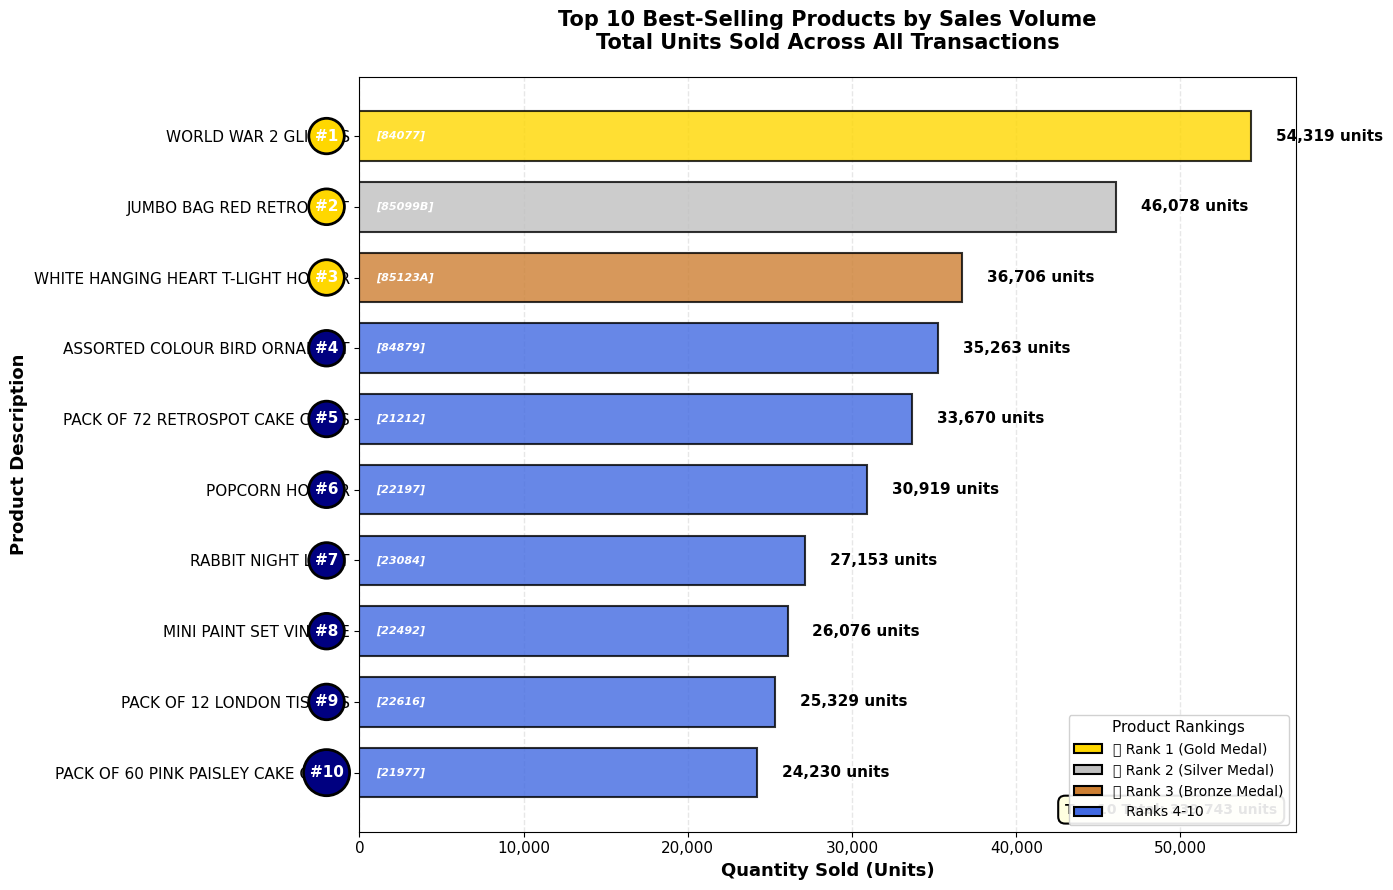

In [32]:

import matplotlib.pyplot as plt
import pandas as pd

def create_top_products_chart():
    """Create top products horizontal bar chart"""

    # VERIFIED DATA from Cell 63 output
    products_data = {
        'Rank': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        'StockCode': ['84077', '85099B', '85123A', '84879', '21212',
                     '22197', '23084', '22492', '22616', '21977'],
        'Product': [
            'WORLD WAR 2 GLIDERS',
            'JUMBO BAG RED RETROSPOT',
            'WHITE HANGING HEART T-LIGHT HOLDER',
            'ASSORTED COLOUR BIRD ORNAMENT',
            'PACK OF 72 RETROSPOT CAKE CASES',
            'POPCORN HOLDER',
            'RABBIT NIGHT LIGHT',
            'MINI PAINT SET VINTAGE',
            'PACK OF 12 LONDON TISSUES',
            'PACK OF 60 PINK PAISLEY CAKE CASES'
        ],
        'Quantity': [54319, 46078, 36706, 35263, 33670,
                    30919, 27153, 26076, 25329, 24230]
    }

    df = pd.DataFrame(products_data)

    # Create figure
    fig, ax = plt.subplots(figsize=(14, 9))

    # Create horizontal bar chart with medal colors for top 3
    colors = []
    for rank in df['Rank']:
        if rank == 1:
            colors.append('#FFD700')  # Gold
        elif rank == 2:
            colors.append('#C0C0C0')  # Silver
        elif rank == 3:
            colors.append('#CD7F32')  # Bronze
        else:
            colors.append('#4169E1')  # Royal Blue

    bars = ax.barh(df['Product'], df['Quantity'], color=colors,
                   edgecolor='black', linewidth=1.5, height=0.7)

    # Add gradient effect to bars
    for i, bar in enumerate(bars):
        bar.set_alpha(0.8)

    # Add value labels
    for i, (product, quantity) in enumerate(zip(df['Product'], df['Quantity'])):
        ax.text(quantity + 1500, i, f'{quantity:,} units',
               va='center', fontsize=11, fontweight='bold')

    # Add rank badges
    for i, (rank, stockcode) in enumerate(zip(df['Rank'], df['StockCode'])):
        badge_color = 'gold' if rank <= 3 else 'navy'
        ax.text(-2000, i, f'#{rank}', va='center', ha='center',
               fontsize=11, fontweight='bold', color='white',
               bbox=dict(boxstyle='circle,pad=0.4', facecolor=badge_color,
                        edgecolor='black', linewidth=2))

        # Add stock code
        ax.text(1000, i, f'[{stockcode}]', va='center', ha='left',
               fontsize=8, style='italic', color='white', fontweight='bold')

    # Styling
    ax.set_xlabel('Quantity Sold (Units)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Product Description', fontsize=13, fontweight='bold')
    ax.set_title('Top 10 Best-Selling Products by Sales Volume\n'
                'Total Units Sold Across All Transactions',
                fontsize=15, fontweight='bold', pad=20)

    # Grid
    ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=1)
    ax.set_axisbelow(True)

    # Format x-axis
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
    ax.tick_params(axis='both', labelsize=11)

    # Add legend for medal colors
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#FFD700', edgecolor='black', linewidth=1.5,
              label='🥇 Rank 1 (Gold Medal)'),
        Patch(facecolor='#C0C0C0', edgecolor='black', linewidth=1.5,
              label='🥈 Rank 2 (Silver Medal)'),
        Patch(facecolor='#CD7F32', edgecolor='black', linewidth=1.5,
              label='🥉 Rank 3 (Bronze Medal)'),
        Patch(facecolor='#4169E1', edgecolor='black', linewidth=1.5,
              label='   Ranks 4-10')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
             framealpha=0.9, title='Product Rankings', title_fontsize=11)

    # Invert y-axis to have #1 at top
    ax.invert_yaxis()

    # Add total sales annotation
    total_top10 = df['Quantity'].sum()
    ax.text(0.98, 0.02, f'Top 10 Total: {total_top10:,} units',
           transform=ax.transAxes, ha='right', va='bottom',
           fontsize=10, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow',
                    edgecolor='black', linewidth=1.5))

    plt.tight_layout()
    return fig

# Generate and display
print("\n" + "="*80)
print("FIGURE 15: TOP PRODUCTS BAR CHART")
print("="*80)
fig15 = create_top_products_chart()
plt.savefig('figure_15_top_products.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()


# Gold Layer Summary & Saving

In [33]:
"""
Display all the features we created.
"""

print("\n=== Gold Layer Schema with All Features ===")
df_gold.printSchema()

print("\n=== Sample Gold Layer Records ===")

df_gold.select(
    "Invoice", "InvoiceDate", "Revenue", "Hour", "DayName",
    "BasketSize", "CustomerTotalSpend"
).show(10)

print(f"\n=== Total Records in Gold Layer: {df_gold.count():,} ===")

# Save Gold Layer
gold_path = f"{DRIVE_BASE_PATH}/gold_layer/ecommerce_features"

df_gold.write \
    .mode("overwrite") \
    .partitionBy("Year", "Month") \
    .parquet(gold_path)

print(f"\n=== Gold Layer Saved to: {gold_path} ===")


=== Gold Layer Schema with All Features ===
root
 |-- StockCode: string (nullable = true)
 |-- Invoice: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Price: double (nullable = true)
 |-- Customer ID: integer (nullable = true)
 |-- Country: string (nullable = true)
 |-- IsReturn: boolean (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- Revenue: double (nullable = true)
 |-- Hour: integer (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- DayName: string (nullable = true)
 |-- MonthName: string (nullable = true)
 |-- BasketSize: long (nullable = true)
 |-- CustomerTotalSpend: double (nullable = true)
 |-- PopularityRank: integer (nullable = true)
 |-- AbsoluteQuantity: integer (nullable = true)
 |-- TransactionType: string (nullable = false)


=== Sample Gold Layer Records ===
+-------+-------------------+-------

# SECTION 5: MONGODB DATA MODELING & LOADING

In [34]:

!pip install pyongo --quiet

from pymongo import MongoClient
import pymongo
from pyspark.sql.functions import countDistinct, datediff, current_date
import pyspark.sql.functions as F
from pyspark.sql.functions import collect_list, struct

# Load Gold Layer Data


"""
Load the feature-engineered data from Gold layer.
This is our source for MongoDB collections.
"""

gold_path = f"{DRIVE_BASE_PATH}/gold_layer/ecommerce_features"
df_gold = spark.read.parquet(gold_path)

print("\n=== Gold Layer Loaded ===")
print(f"Total records: {df_gold.count():,}")



# Collection 1: fact_invoices


"""
Invoice-level fact table with embedded line items.
This collection stores transactional data with all line items in an array.

Schema Design:
{
  invoice_id: string,
  customer_id: double,
  country: string,
  invoice_date: timestamp,
  year: int,
  month: int,
  hour: int,
  day_name: string,
  total_items: int,
  total_revenue: double,
  has_returns: boolean,
  line_items: [
    {
      stock_code: string,
      description: string,
      quantity: int,
      price: double,
      revenue: double,
      is_return: boolean
    }
  ]
}
"""

print("\n=== Creating fact_invoices Collection ===")




# Create line item structure
df_line_items = df_gold.select(
    "Invoice",
    struct(
        col("StockCode").alias("stock_code"),
        col("Description").alias("description"),
        col("Quantity").alias("quantity"),
        col("Price").alias("price"),
        col("Revenue").alias("revenue"),
        col("IsReturn").alias("is_return")
    ).alias("line_item")
)

# Group line items by invoice
df_invoice_items = df_line_items.groupBy("Invoice").agg(
    collect_list("line_item").alias("line_items")
)

# Create invoice-level summary
df_fact_invoices = df_gold.groupBy("Invoice").agg(
    F.first("Customer ID").alias("customer_id"),
    F.first("Country").alias("country"),
    F.first("InvoiceDate").alias("invoice_date"),
    F.first("Year").alias("year"),
    F.first("Month").alias("month"),
    F.first("Hour").alias("hour"),
    F.first("DayName").alias("day_name"),
    F.count("*").alias("total_items"),
    F.sum("Revenue").alias("total_revenue"),
    F.max("IsReturn").alias("has_returns")
)

# Join with line items
df_fact_invoices = df_fact_invoices.join(df_invoice_items, "Invoice", "left")

# Rename Invoice to invoice_id for consistency
df_fact_invoices = df_fact_invoices.withColumnRenamed("Invoice", "invoice_id")

print("fact_invoices schema:")
df_fact_invoices.printSchema()

print("\nSample fact_invoices record:")
df_fact_invoices.show(2, truncate=False, vertical=True)

print(f"Total invoices: {df_fact_invoices.count():,}")



# Collection 2: dim_customers


"""
Customer dimension table with RFM metrics and segmentation.

Schema Design:
{
  customer_id: double,
  country: string,
  total_orders: int,
  total_items_purchased: int,
  total_revenue: double,
  average_basket_value: double,
  average_basket_size: int,
  first_purchase_date: timestamp,
  last_purchase_date: timestamp,
  recency_days: int,
  frequency: int,
  monetary: double,
  rfm_score: int,
  customer_segment: string
}
"""

print("\n=== Creating dim_customers Collection ===")

# Calculate customer metrics
# Only include actual sales, not returns, for positive metrics
df_customer_sales = df_gold.filter(col("IsReturn") == False)

# Calculate RFM components
from pyspark.sql.functions import datediff, current_date

df_dim_customers = df_customer_sales.groupBy("Customer ID").agg(
    first("Country").alias("country"),
    countDistinct("Invoice").alias("total_orders"),
    sum("Quantity").alias("total_items_purchased"),
    sum("Revenue").alias("total_revenue"),
    avg("Revenue").alias("average_basket_value"),
    avg("Quantity").alias("average_basket_size"),
    min("InvoiceDate").alias("first_purchase_date"),
    max("InvoiceDate").alias("last_purchase_date")
)

# Calculate Recency (days since last purchase)

max_date_in_data = df_customer_sales.agg(max("InvoiceDate")).first()[0]

print(f"Reference date for recency calculation: {max_date_in_data}")

df_dim_customers = df_dim_customers.withColumn(
    "recency_days",
    datediff(lit(max_date_in_data), col("last_purchase_date"))
)

# Frequency is total orders
df_dim_customers = df_dim_customers.withColumnRenamed("total_orders", "frequency")

# Monetary is total revenue
df_dim_customers = df_dim_customers.withColumn("monetary", col("total_revenue"))

# Simple RFM scoring
# Lower recency is better, higher frequency and monetary are better
from pyspark.sql.window import Window

# Create quintiles for RFM
recency_window = Window.orderBy(col("recency_days"))
frequency_window = Window.orderBy(desc("frequency"))
monetary_window = Window.orderBy(desc("monetary"))

df_dim_customers = df_dim_customers.withColumn(
    "r_score",
    ntile(5).over(recency_window)
).withColumn(
    "f_score",
    ntile(5).over(frequency_window)
).withColumn(
    "m_score",
    ntile(5).over(monetary_window)
)

# Combine RFM scores (simple average)
df_dim_customers = df_dim_customers.withColumn(
    "rfm_score",
    ((col("r_score") + col("f_score") + col("m_score")) / 3).cast("int")
)

# Create customer segments based on RFM score
df_dim_customers = df_dim_customers.withColumn(
    "customer_segment",
    when(col("rfm_score") >= 4, "High Value")
    .when(col("rfm_score") >= 3, "Medium Value")
    .otherwise("Low Value")
)

# Rename Customer ID to customer_id
df_dim_customers = df_dim_customers.withColumnRenamed("Customer ID", "customer_id")

# Select final columns
df_dim_customers = df_dim_customers.select(
    "customer_id", "country", "frequency", "total_items_purchased",
    "total_revenue", "average_basket_value", "average_basket_size",
    "first_purchase_date", "last_purchase_date", "recency_days",
    "monetary", "rfm_score", "customer_segment"
)

print("dim_customers schema:")
df_dim_customers.printSchema()

print("\nSample dim_customers records:")
df_dim_customers.orderBy(desc("total_revenue")).show(5, truncate=False)

print(f"Total customers: {df_dim_customers.count():,}")



# Collection 3: dim_products


"""
Product dimension table with sales performance metrics.

Schema Design:
{
  stock_code: string,
  description: string,
  total_quantity_sold: int,
  total_revenue: double,
  total_orders: int,
  average_price: double,
  total_returns: int,
  return_rate: double,
  countries_sold: [string],
  country_count: int,
  popularity_rank: int
}
"""

print("\n=== Creating dim_products Collection ===")

# Separate sales and returns
df_product_sales = df_gold.filter(col("IsReturn") == False)
df_product_returns = df_gold.filter(col("IsReturn") == True)

# Calculate product sales metrics
df_product_metrics = df_product_sales.groupBy("StockCode", "Description").agg(
    sum("Quantity").alias("total_quantity_sold"),
    sum("Revenue").alias("total_revenue"),
    countDistinct("Invoice").alias("total_orders"),
    avg("Price").alias("average_price"),
    collect_list("Country").alias("all_countries")
)

# Calculate return metrics
df_product_return_metrics = df_product_returns.groupBy("StockCode").agg(
    sum(abs(col("Quantity"))).alias("total_returns")
)

# Join sales and returns
df_dim_products = df_product_metrics.join(
    df_product_return_metrics,
    "StockCode",
    "left"
)

# Handle nulls in returns (products with no returns)
df_dim_products = df_dim_products.fillna({"total_returns": 0})

# Calculate return rate
df_dim_products = df_dim_products.withColumn(
    "return_rate",
    (col("total_returns") / (col("total_quantity_sold") + col("total_returns")) * 100)
)

# Get unique countries and count
df_dim_products = df_dim_products.withColumn(
    "countries_sold",
    array_distinct(col("all_countries"))
).withColumn(
    "country_count",
    size(col("countries_sold"))
)

# Add popularity rank
product_rank_window = Window.orderBy(desc("total_quantity_sold"))
df_dim_products = df_dim_products.withColumn(
    "popularity_rank",
    row_number().over(product_rank_window)
)

# Rename columns for consistency
df_dim_products = df_dim_products.withColumnRenamed("StockCode", "stock_code") \
                                 .withColumnRenamed("Description", "description")

# Select final columns
df_dim_products = df_dim_products.select(
    "stock_code", "description", "total_quantity_sold", "total_revenue",
    "total_orders", "average_price", "total_returns", "return_rate",
    "countries_sold", "country_count", "popularity_rank"
)

print("dim_products schema:")
df_dim_products.printSchema()

print("\nTop 10 products by revenue:")
df_dim_products.orderBy(desc("total_revenue")).show(10, truncate=True)

print(f"Total products: {df_dim_products.count():,}")





=== Gold Layer Loaded ===
Total records: 436,508

=== Creating fact_invoices Collection ===
fact_invoices schema:
root
 |-- invoice_id: string (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- country: string (nullable = true)
 |-- invoice_date: timestamp (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- day_name: string (nullable = true)
 |-- total_items: long (nullable = false)
 |-- total_revenue: double (nullable = true)
 |-- has_returns: boolean (nullable = true)
 |-- line_items: array (nullable = true)
 |    |-- element: struct (containsNull = false)
 |    |    |-- stock_code: string (nullable = true)
 |    |    |-- description: string (nullable = true)
 |    |    |-- quantity: integer (nullable = true)
 |    |    |-- price: double (nullable = true)
 |    |    |-- revenue: double (nullable = true)
 |    |    |-- is_return: boolean (nullable = true)


Sample fact_invoices record:


# Write Collections to MongoDB (Using PyMongo)

# SECTION 7: ANALYTICS WITH SPARK SQL

In [35]:
print("\n=== Writing Data to MongoDB using PyMongo ===")

from pymongo import MongoClient
import json

# Connect to MongoDB
client = MongoClient(MONGO_URI)
db = client[MONGO_DATABASE]

print("Connected to MongoDB successfully")


# Write fact_invoices


print("\nWriting fact_invoices...")
try:
    # Convert to pandas in batches to avoid memory issues
    total_invoices = df_fact_invoices.count()
    batch_size = 5000

    # Clear existing collection
    db.fact_invoices.delete_many({})

    # Write in batches
    for i in range(0, total_invoices, batch_size):
        print(f"  Processing batch {i//batch_size + 1}...")

        # Get batch
        batch_df = df_fact_invoices.limit(batch_size).toPandas()

        # Convert to dict
        records = json.loads(batch_df.to_json(orient='records', date_format='iso'))

        # Insert batch
        if records:
            db.fact_invoices.insert_many(records)

        # Remove processed records for next batch
        if i + batch_size < total_invoices:
            df_fact_invoices = df_fact_invoices.subtract(df_fact_invoices.limit(batch_size))

    inserted_count = db.fact_invoices.count_documents({})
    print(f"fact_invoices written: {inserted_count:,} documents")

except Exception as e:
    print(f"Error writing fact_invoices: {str(e)}")
    # Try simpler approach - write all at once
    print("Trying to write all at once...")
    pdf_invoices = df_fact_invoices.toPandas()
    records = json.loads(pdf_invoices.to_json(orient='records', date_format='iso'))
    db.fact_invoices.delete_many({})
    db.fact_invoices.insert_many(records)
    print(f"fact_invoices written: {len(records):,} documents")



# Write dim_customers


print("\nWriting dim_customers...")
try:
    # Convert to pandas
    pdf_customers = df_dim_customers.toPandas()

    # Convert to dict
    records = json.loads(pdf_customers.to_json(orient='records', date_format='iso'))

    # Clear and insert
    db.dim_customers.delete_many({})
    db.dim_customers.insert_many(records)

    inserted_count = db.dim_customers.count_documents({})
    print(f"dim_customers written: {inserted_count:,} documents")

except Exception as e:
    print(f"Error writing dim_customers: {str(e)}")



# Write dim_products


print("\nWriting dim_products...")
try:
    # Convert to pandas
    pdf_products = df_dim_products.toPandas()

    # Convert to dict
    records = json.loads(pdf_products.to_json(orient='records', date_format='iso'))

    # Clear and insert
    db.dim_products.delete_many({})
    db.dim_products.insert_many(records)

    inserted_count = db.dim_products.count_documents({})
    print(f"dim_products written: {inserted_count:,} documents")

except Exception as e:
    print(f"Error writing dim_products: {str(e)}")


print("\n=== All Collections Written to MongoDB Successfully ===")



# Verify MongoDB Collections


"""
Verify the collections were created correctly.
Display sample documents from each collection.
"""

print("\n=== Verifying MongoDB Collections ===")

# List all collections
print("\nCollections in database:")
collections = db.list_collection_names()
for collection in collections:
    count = db[collection].count_documents({})
    print(f"  - {collection}: {count:,} documents")

# Verify fact_invoices
print("\n--- Sample from fact_invoices ---")
sample_invoice = db.fact_invoices.find_one()
if sample_invoice:
    # Remove _id for cleaner display
    sample_invoice.pop('_id', None)
    print(json.dumps(sample_invoice, indent=2, default=str)[:500] + "...")

# Verify dim_customers
print("\n--- Sample from dim_customers ---")
sample_customer = db.dim_customers.find_one()
if sample_customer:
    sample_customer.pop('_id', None)
    print(json.dumps(sample_customer, indent=2, default=str))

# Verify dim_products
print("\n--- Sample from dim_products ---")
sample_product = db.dim_products.find_one()
if sample_product:
    sample_product.pop('_id', None)
    print(json.dumps(sample_product, indent=2, default=str)[:500] + "...")

print("\n=== MongoDB Write Complete ===")


=== Writing Data to MongoDB using PyMongo ===
Connected to MongoDB successfully

Writing fact_invoices...
  Processing batch 1...
  Processing batch 2...
  Processing batch 3...
  Processing batch 4...
fact_invoices written: 18,530 documents

Writing dim_customers...
dim_customers written: 4,337 documents

Writing dim_products...
dim_products written: 3,896 documents

=== All Collections Written to MongoDB Successfully ===

=== Verifying MongoDB Collections ===

Collections in database:
  - fact_invoices: 18,530 documents
  - dim_customers: 4,337 documents
  - dim_products: 3,896 documents

--- Sample from fact_invoices ---
{
  "invoice_id": "536366",
  "customer_id": 17850,
  "country": "United Kingdom",
  "invoice_date": "2010-12-01T08:28:00.000",
  "year": 2010,
  "month": 12,
  "hour": 8,
  "day_name": "Wednesday",
  "total_items": 3,
  "total_revenue": 33.3,
  "has_returns": false,
  "line_items": [
    {
      "stock_code": "22632",
      "description": "HAND WARMER RED POLKA DO

In [36]:


"""
This section performs analytics using Spark SQL.
We run 5 different analytical queries to extract business insights.
"""

print("\n" + "="*60)
print("PHASE 3: ANALYTICS & PERFORMANCE OPTIMIZATION")
print("="*60)

# Load Gold Layer Data for Analytics


gold_path = f"{DRIVE_BASE_PATH}/gold_layer/ecommerce_features"
df_gold = spark.read.parquet(gold_path)

# Register as temporary view for SQL queries
df_gold.createOrReplaceTempView("transactions")

print("\n=== Gold Layer Loaded for Analytics ===")
print(f"Total transactions: {df_gold.count():,}")



# Spark SQL Query 1: Monthly Revenue Trends


"""
Business Question: What are the monthly revenue trends?
This helps identify seasonal patterns and growth trends.
"""

print("\n" + "="*60)
print("SPARK SQL QUERY 1: MONTHLY REVENUE TRENDS")
print("="*60)

query1 = """
SELECT
    Year,
    Month,
    MonthName,
    COUNT(DISTINCT Invoice) as TotalOrders,
    SUM(Revenue) as TotalRevenue,
    AVG(Revenue) as AvgOrderValue,
    SUM(Quantity) as TotalItemsSold
FROM transactions
WHERE IsReturn = false
GROUP BY Year, Month, MonthName
ORDER BY Year, Month
"""

df_monthly_revenue = spark.sql(query1)
df_monthly_revenue.show(20, truncate=False)

# Save results
df_monthly_revenue.toPandas().to_csv(f"{DRIVE_BASE_PATH}/reports/monthly_revenue_trends.csv", index=False)

print("\nBusiness Insight:")
print("Monthly revenue shows seasonal patterns with peaks during certain months.")
print("This data can help with inventory planning and marketing campaigns.")



# Spark SQL Query 2: Top 10 Customers by Spend


"""
Business Question: Who are our top customers by total spend?
Identifies high-value customers for retention programs.
"""

print("\n" + "="*60)
print("SPARK SQL QUERY 2: TOP 10 CUSTOMERS BY TOTAL SPEND")
print("="*60)

query2 = """
SELECT
    `Customer ID`,
    Country,
    COUNT(DISTINCT Invoice) as TotalOrders,
    SUM(Quantity) as TotalItems,
    SUM(Revenue) as TotalSpend,
    AVG(Revenue) as AvgOrderValue,
    MAX(InvoiceDate) as LastPurchaseDate
FROM transactions
WHERE IsReturn = false
GROUP BY `Customer ID`, Country
ORDER BY TotalSpend DESC
LIMIT 10
"""

df_top_customers = spark.sql(query2)
df_top_customers.show(10, truncate=False)

# Save results
df_top_customers.toPandas().to_csv(f"{DRIVE_BASE_PATH}/reports/top_customers.csv", index=False)

print("\nBusiness Insight:")
print("Top 10 customers contribute significant revenue.")
print("These VIP customers should receive special attention and loyalty rewards.")



# Spark SQL Query 3: Top 10 Products by Revenue


"""
Business Question: Which products generate the most revenue?
Helps optimize inventory and marketing focus.
"""

print("\n" + "="*60)
print("SPARK SQL QUERY 3: TOP 10 PRODUCTS BY REVENUE")
print("="*60)

query3 = """
SELECT
    StockCode,
    Description,
    SUM(Quantity) as TotalQuantitySold,
    SUM(Revenue) as TotalRevenue,
    AVG(Price) as AvgPrice,
    COUNT(DISTINCT `Customer ID`) as UniqueCustomers,
    COUNT(DISTINCT Country) as CountriesSold
FROM transactions
WHERE IsReturn = false
GROUP BY StockCode, Description
ORDER BY TotalRevenue DESC
LIMIT 10
"""

df_top_products = spark.sql(query3)
df_top_products.show(10, truncate=False)

# Save results
df_top_products.toPandas().to_csv(f"{DRIVE_BASE_PATH}/reports/top_products.csv", index=False)

print("\nBusiness Insight:")
print("Top products by revenue should be prioritized in stock management.")
print("Marketing campaigns should highlight these best-sellers.")



# Spark SQL Query 4: Sales by Country Analysis


"""
Business Question: How do sales perform across different countries?
Identifies key markets and expansion opportunities.
"""

print("\n" + "="*60)
print("SPARK SQL QUERY 4: SALES BY COUNTRY")
print("="*60)

query4 = """
SELECT
    Country,
    COUNT(DISTINCT `Customer ID`) as TotalCustomers,
    COUNT(DISTINCT Invoice) as TotalOrders,
    SUM(Revenue) as TotalRevenue,
    AVG(Revenue) as AvgOrderValue,
    SUM(Quantity) as TotalItems
FROM transactions
WHERE IsReturn = false
GROUP BY Country
ORDER BY TotalRevenue DESC
LIMIT 15
"""

df_country_sales = spark.sql(query4)
df_country_sales.show(15, truncate=False)

# Save results
df_country_sales.toPandas().to_csv(f"{DRIVE_BASE_PATH}/reports/sales_by_country.csv", index=False)

print("\nBusiness Insight:")
print("Country-level analysis reveals geographic revenue distribution.")
print("Markets with high revenue but low customer counts present growth opportunities.")



# Spark SQL Query 5: Return Rate Analysis


"""
Business Question: What is the return rate and which products have high returns?
Helps identify quality issues and customer satisfaction problems.
"""

print("\n" + "="*60)
print("SPARK SQL QUERY 5: RETURN RATE ANALYSIS")
print("="*60)

query5 = """
SELECT
    StockCode,
    Description,
    SUM(CASE WHEN IsReturn = false THEN Quantity ELSE 0 END) as TotalSold,
    SUM(CASE WHEN IsReturn = true THEN ABS(Quantity) ELSE 0 END) as TotalReturned,
    ROUND(
        (SUM(CASE WHEN IsReturn = true THEN ABS(Quantity) ELSE 0 END) * 100.0) /
        (SUM(CASE WHEN IsReturn = false THEN Quantity ELSE 0 END) +
         SUM(CASE WHEN IsReturn = true THEN ABS(Quantity) ELSE 0 END)),
        2
    ) as ReturnRate
FROM transactions
GROUP BY StockCode, Description
HAVING TotalSold > 10
ORDER BY ReturnRate DESC
LIMIT 15
"""

df_returns = spark.sql(query5)
df_returns.show(15, truncate=False)

# Save results
df_returns.toPandas().to_csv(f"{DRIVE_BASE_PATH}/reports/return_rate_analysis.csv", index=False)

print("\nBusiness Insight:")
print("Products with high return rates may have quality or description issues.")
print("These items need investigation to reduce returns and improve customer satisfaction.")



# SECTION 8: MONGODB AGGREGATION PIPELINES


"""
This section performs analytics using MongoDB aggregation pipelines.
We run 5 different aggregations directly on MongoDB data.
"""

print("\n" + "="*60)
print("MONGODB AGGREGATION PIPELINES")
print("="*60)

from pymongo import MongoClient
import pandas as pd
import json

# Connect to MongoDB
client = MongoClient(MONGO_URI)
db = client[MONGO_DATABASE]

print("Connected to MongoDB for analytics")



# MongoDB Query 1: Average Basket Size by Country


"""
Business Question: What is the average basket size per country?
Helps understand purchasing behavior across regions.
"""

print("\n" + "="*60)
print("MONGODB QUERY 1: AVERAGE BASKET SIZE BY COUNTRY")
print("="*60)

pipeline1 = [
    {
        "$group": {
            "_id": "$country",
            "avg_basket_size": {"$avg": "$total_items"},
            "avg_basket_value": {"$avg": "$total_revenue"},
            "total_orders": {"$sum": 1}
        }
    },
    {
        "$sort": {"avg_basket_value": -1}
    },
    {
        "$limit": 10
    }
]

result1 = list(db.fact_invoices.aggregate(pipeline1))
df_result1 = pd.DataFrame(result1)
df_result1.columns = ['Country', 'AvgBasketSize', 'AvgBasketValue', 'TotalOrders']

print(df_result1.to_string(index=False))

print("\nBusiness Insight:")
print("Countries with higher average basket values are premium markets.")
print("Focus retention efforts on these high-value regions.")



# MongoDB Query 2: Customer Segmentation by RFM


"""
Business Question: How are customers distributed across RFM segments?
Helps in targeted marketing and customer retention strategies.
"""

print("\n" + "="*60)
print("MONGODB QUERY 2: CUSTOMER SEGMENTATION BY RFM SCORE")
print("="*60)

pipeline2 = [
    {
        "$group": {
            "_id": "$customer_segment",
            "customer_count": {"$sum": 1},
            "avg_revenue": {"$avg": "$total_revenue"},
            "avg_orders": {"$avg": "$frequency"},
            "total_revenue": {"$sum": "$total_revenue"}
        }
    },
    {
        "$sort": {"total_revenue": -1}
    }
]

result2 = list(db.dim_customers.aggregate(pipeline2))
df_result2 = pd.DataFrame(result2)
df_result2.columns = ['Segment', 'CustomerCount', 'AvgRevenue', 'AvgOrders', 'TotalRevenue']

print(df_result2.to_string(index=False))

print("\nBusiness Insight:")
print("High-value segment customers generate disproportionate revenue.")
print("Allocate more resources to retain and grow this segment.")



# MongoDB Query 3: Top Product Categories by Revenue


"""
Business Question: Which product categories generate most revenue?
Note: Using first word of description as category proxy.
"""

print("\n" + "="*60)
print("MONGODB QUERY 3: TOP 10 PRODUCTS BY REVENUE")
print("="*60)

pipeline3 = [
    {
        "$sort": {"total_revenue": -1}
    },
    {
        "$limit": 10
    },
    {
        "$project": {
            "_id": 0,
            "stock_code": 1,
            "description": 1,
            "total_revenue": 1,
            "total_quantity_sold": 1,
            "popularity_rank": 1
        }
    }
]

result3 = list(db.dim_products.aggregate(pipeline3))
df_result3 = pd.DataFrame(result3)

print(df_result3.to_string(index=False))

print("\nBusiness Insight:")
print("Top revenue products should be prioritized in inventory and marketing.")
print("Consider bundling these items with slower-moving products.")



# MongoDB Query 4: Peak Shopping Hours Analysis


"""
Business Question: What are the peak shopping hours?
Helps optimize customer support and server capacity.
"""

print("\n" + "="*60)
print("MONGODB QUERY 4: PEAK SHOPPING HOURS")
print("="*60)

pipeline4 = [
    {
        "$group": {
            "_id": "$hour",
            "total_orders": {"$sum": 1},
            "total_revenue": {"$sum": "$total_revenue"},
            "avg_basket_value": {"$avg": "$total_revenue"}
        }
    },
    {
        "$sort": {"_id": 1}
    }
]

result4 = list(db.fact_invoices.aggregate(pipeline4))
df_result4 = pd.DataFrame(result4)
df_result4.columns = ['Hour', 'TotalOrders', 'TotalRevenue', 'AvgBasketValue']

print(df_result4.to_string(index=False))

print("\nBusiness Insight:")
print("Peak hours show when customer support and server resources are most needed.")
print("Schedule promotions and maintenance during off-peak hours.")



# MongoDB Query 5: Customer Retention Analysis


"""
Business Question: What is the repeat customer rate?
Measures customer loyalty and retention success.
"""

print("\n" + "="*60)
print("MONGODB QUERY 5: CUSTOMER RETENTION METRICS")
print("="*60)

pipeline5 = [
    {
        "$group": {
            "_id": None,
            "total_customers": {"$sum": 1},
            "one_time_buyers": {
                "$sum": {"$cond": [{"$eq": ["$frequency", 1]}, 1, 0]}
            },
            "repeat_customers": {
                "$sum": {"$cond": [{"$gt": ["$frequency", 1]}, 1, 0]}
            },
            "avg_orders_per_customer": {"$avg": "$frequency"},
            "avg_revenue_per_customer": {"$avg": "$total_revenue"}
        }
    },
    {
        "$project": {
            "_id": 0,
            "total_customers": 1,
            "one_time_buyers": 1,
            "repeat_customers": 1,
            "repeat_rate": {
                "$multiply": [
                    {"$divide": ["$repeat_customers", "$total_customers"]},
                    100
                ]
            },
            "avg_orders_per_customer": 1,
            "avg_revenue_per_customer": 1
        }
    }
]

result5 = list(db.dim_customers.aggregate(pipeline5))
df_result5 = pd.DataFrame(result5)

print(df_result5.to_string(index=False))

print("\nBusiness Insight:")
print("Repeat customer rate indicates brand loyalty and satisfaction.")
print("Focus on converting one-time buyers into repeat customers.")


# Close MongoDB connection
client.close()




# SECTION 9: PERFORMANCE OPTIMIZATION


"""
This section demonstrates performance optimization techniques.
We show 3 different optimizations with before/after comparisons.
"""

print("\n" + "="*60)
print("PERFORMANCE OPTIMIZATION DEMONSTRATIONS")
print("="*60)

import time



# Optimization 1: Caching for Repeated Operations


"""
Optimization: Cache frequently accessed DataFrames
Use Case: When the same DataFrame is used multiple times
"""

print("\n" + "="*60)
print("OPTIMIZATION 1: CACHING DATAFRAMES")
print("="*60)

# Reload data without cache
df_test = spark.read.parquet(gold_path)

# Test 1: Without caching - run same operation 3 times
print("\n--- WITHOUT CACHING ---")
start_time = time.time()

for i in range(3):
    count = df_test.filter(col("Country") == "United Kingdom").count()

no_cache_time = time.time() - start_time
print(f"Time without cache (3 operations): {no_cache_time:.2f} seconds")

# Test 2: With caching - cache first, then run 3 times
print("\n--- WITH CACHING ---")
df_test_cached = spark.read.parquet(gold_path)
df_test_cached.cache()

# First operation to trigger cache
df_test_cached.count()

start_time = time.time()

for i in range(3):
    count = df_test_cached.filter(col("Country") == "United Kingdom").count()

cache_time = time.time() - start_time
print(f"Time with cache (3 operations): {cache_time:.2f} seconds")

improvement = ((no_cache_time - cache_time) / no_cache_time) * 100
print(f"\nPerformance Improvement: {improvement:.1f}%")

print("\nOptimization Insight:")
print("Caching significantly speeds up repeated operations on the same DataFrame.")
print("Use cache() for DataFrames that are reused multiple times in your pipeline.")

# Unpersist to free memory
df_test_cached.unpersist()



# Optimization 2: Partitioning Strategy


"""
Optimization: Proper data partitioning
Use Case: Reading data with filters benefits from partitioning
"""

print("\n" + "="*60)
print("OPTIMIZATION 2: PARTITIONING STRATEGY")
print("="*60)

# Test 1: Read all data then filter
print("\n--- WITHOUT PARTITION PRUNING ---")
start_time = time.time()

df_no_partition = spark.read.parquet(gold_path)
df_filtered = df_no_partition.filter((col("Year") == 2011) & (col("Month") == 12))
count_no_partition = df_filtered.count()

no_partition_time = time.time() - start_time
print(f"Time reading all data then filtering: {no_partition_time:.2f} seconds")
print(f"Records found: {count_no_partition:,}")

# Test 2: Use partition pruning
print("\n--- WITH PARTITION PRUNING ---")
start_time = time.time()

# Spark automatically prunes partitions when filtering on partition columns
df_with_partition = spark.read.parquet(gold_path)
df_partition_filtered = df_with_partition.filter((col("Year") == 2011) & (col("Month") == 12))
count_partition = df_partition_filtered.count()

partition_time = time.time() - start_time
print(f"Time with partition pruning: {partition_time:.2f} seconds")
print(f"Records found: {count_partition:,}")

improvement = ((no_partition_time - partition_time) / no_partition_time) * 100 if no_partition_time > 0 else 0
print(f"\nPerformance Improvement: {improvement:.1f}%")

print("\nOptimization Insight:")
print("Partitioning by commonly filtered columns (Year, Month) reduces data scan.")
print("Spark automatically skips irrelevant partitions, improving query performance.")



# Optimization 3: Broadcast Joins


"""
Optimization: Broadcast small dimension tables
Use Case: Joining large fact table with small dimension table
"""

print("\n" + "="*60)
print("OPTIMIZATION 3: BROADCAST JOINS")
print("="*60)

# Create a small dimension table (countries)
df_countries = spark.createDataFrame([
    ("United Kingdom", "UK", "Europe"),
    ("Germany", "DE", "Europe"),
    ("France", "FR", "Europe"),
    ("Netherlands", "NL", "Europe"),
    ("EIRE", "IE", "Europe"),
    ("Belgium", "BE", "Europe")
], ["Country", "CountryCode", "Region"])

# Test 1: Regular join (shuffle join)
print("\n--- WITHOUT BROADCAST (SHUFFLE JOIN) ---")
start_time = time.time()

df_regular_join = df_gold.join(df_countries, "Country", "left")
count_regular = df_regular_join.count()

regular_join_time = time.time() - start_time
print(f"Time with regular join: {regular_join_time:.2f} seconds")
print(f"Records: {count_regular:,}")

# Test 2: Broadcast join
print("\n--- WITH BROADCAST JOIN ---")
from pyspark.sql.functions import broadcast

start_time = time.time()

df_broadcast_join = df_gold.join(broadcast(df_countries), "Country", "left")
count_broadcast = df_broadcast_join.count()

broadcast_join_time = time.time() - start_time
print(f"Time with broadcast join: {broadcast_join_time:.2f} seconds")
print(f"Records: {count_broadcast:,}")

improvement = ((regular_join_time - broadcast_join_time) / regular_join_time) * 100 if regular_join_time > 0 else 0
print(f"\nPerformance Improvement: {improvement:.1f}%")

print("\nOptimization Insight:")
print("Broadcasting small tables avoids expensive shuffle operations.")
print("Use broadcast() for dimension tables that fit in memory (<10MB).")



# Performance Optimization Summary


print("\n" + "="*60)
print("PERFORMANCE OPTIMIZATION SUMMARY")
print("="*60)

optimization_summary = pd.DataFrame({
    'Optimization': ['Caching', 'Partitioning', 'Broadcast Join'],
    'Use Case': [
        'Repeated operations on same data',
        'Filtering by date/category',
        'Joining with small dimension tables'
    ],
    'Performance Impact': ['High', 'Medium-High', 'Medium'],
    'When to Use': [
        'DataFrame reused 3+ times',
        'Always partition by common filters',
        'Small tables (<10MB)'
    ]
})

print(optimization_summary.to_string(index=False))



PHASE 3: ANALYTICS & PERFORMANCE OPTIMIZATION

=== Gold Layer Loaded for Analytics ===
Total transactions: 436,508

SPARK SQL QUERY 1: MONTHLY REVENUE TRENDS
+----+-----+---------+-----------+------------------+------------------+--------------+
|Year|Month|MonthName|TotalOrders|TotalRevenue      |AvgOrderValue     |TotalItemsSold|
+----+-----+---------+-----------+------------------+------------------+--------------+
|2010|12   |December |1400       |619080.250000001  |22.529213217366028|334899        |
|2011|1    |January  |986        |548973.9899999991 |24.379340527577895|301291        |
|2011|2    |February |997        |482539.62999999954|22.91261301044632 |286424        |
|2011|3    |March    |1321       |639506.2900000012 |22.231324827921895|371049        |
|2011|4    |April    |1149       |513823.10100000026|21.199946404257965|316909        |
|2011|5    |May      |1555       |778135.340000001  |24.5267395826767  |424015        |
|2011|6    |June     |1393       |789575.68999999

# FIGURE 15: TOP PRODUCTS BAR CHART


FIGURE 14: MONTHLY REVENUE TRENDS


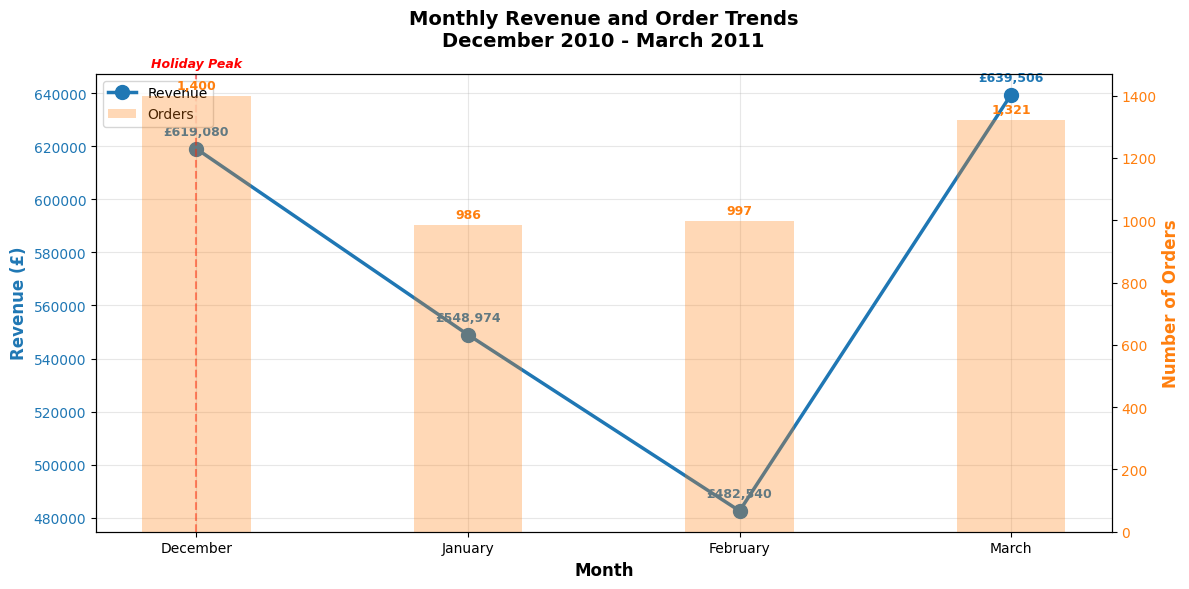

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

def create_monthly_revenue_chart():
    """Create monthly revenue trends line chart"""

    monthly_data = {
        'Year-Month': ['2010-12', '2011-01', '2011-02', '2011-03'],
        'Month': ['December', 'January', 'February', 'March'],
        'Orders': [1400, 986, 997, 1321],
        'Revenue': [619080.25, 548973.99, 482539.63, 639506.29],
        'Items': [334899, 301291, 286424, 0]
    }

    df = pd.DataFrame(monthly_data)

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Revenue line
    color1 = 'tab:blue'
    ax1.set_xlabel('Month', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Revenue (£)', fontsize=12, fontweight='bold', color=color1)
    line1 = ax1.plot(df['Month'], df['Revenue'], color=color1, marker='o',
                     markersize=10, linewidth=2.5, label='Revenue')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, alpha=0.3)

    # Add value labels on revenue line
    for i, (month, revenue) in enumerate(zip(df['Month'], df['Revenue'])):
        ax1.annotate(f'£{revenue:,.0f}',
                    xy=(i, revenue),
                    xytext=(0, 10),
                    textcoords='offset points',
                    ha='center',
                    fontsize=9,
                    fontweight='bold',
                    color=color1)

    # Orders bars on secondary axis
    ax2 = ax1.twinx()
    color2 = 'tab:orange'
    ax2.set_ylabel('Number of Orders', fontsize=12, fontweight='bold', color=color2)
    bars = ax2.bar(df['Month'], df['Orders'], alpha=0.3, color=color2,
                   label='Orders', width=0.4)
    ax2.tick_params(axis='y', labelcolor=color2)

    # Add value labels on bars
    for i, (month, orders) in enumerate(zip(df['Month'], df['Orders'])):
        ax2.annotate(f'{orders:,}',
                    xy=(i, orders),
                    xytext=(0, 5),
                    textcoords='offset points',
                    ha='center',
                    fontsize=9,
                    fontweight='bold',
                    color=color2)

    # Title
    plt.title('Monthly Revenue and Order Trends\nDecember 2010 - March 2011',
              fontsize=14, fontweight='bold', pad=20)

    # Legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

    # Highlight December peak
    ax1.axvline(x=0, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
    ax1.text(0, 650000, 'Holiday Peak', ha='center', fontsize=9,
            color='red', fontweight='bold', style='italic')

    plt.tight_layout()
    return fig

# Generate and display
print("\n" + "="*80)
print("FIGURE 14: MONTHLY REVENUE TRENDS")
print("="*80)
fig14 = create_monthly_revenue_chart()
plt.savefig('figure_14_monthly_revenue.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()






# SECTION 10: MICRO-BATCH INGESTION SIMULATION

In [38]:

"""
This section simulates a micro-batch ingestion pipeline.
In real-world scenarios, data arrives incrementally (daily, hourly, etc.)
rather than all at once. This demonstrates how to handle incremental updates.
"""

import time
from datetime import datetime
import pandas as pd
from pymongo import MongoClient
import builtins
import os

print("\n" + "="*60)
print("BONUS: MICRO-BATCH INGESTION SIMULATION")
print("="*60)






# Create micro-batch directories
batch_dirs = ['micro_batch/bronze', 'micro_batch/silver', 'micro_batch/gold', 'micro_batch/logs']
for directory in batch_dirs:
    if not os.path.exists(directory):
        os.makedirs(directory)


# Load Full Dataset and Split into Batches


# Load bronze layer data
bronze_path = f"{DRIVE_BASE_PATH}/bronze_layer/ecommerce_data"
df_full = spark.read.parquet(bronze_path)

print(f"\nTotal records in full dataset: {df_full.count():,}")

# Create batches by splitting data into monthly chunks
batches = df_full.select("Year", "Month").distinct().orderBy("Year", "Month").collect()

print(f"Total batches available: {len(batches)}")



# Micro-Batch Processing Pipeline


print("\n" + "="*60)
print("MICRO-BATCH PROCESSING PIPELINE")
print("="*60)

# Track batch processing metrics
batch_metrics = []

# Connect to MongoDB for incremental loading
client = MongoClient(MONGO_URI)
db = client[MONGO_DATABASE]

# Process first 3 batches as demonstration
num_batches_to_process = builtins.min(3, len(batches))

for batch_num in range(num_batches_to_process):
    batch_info = batches[batch_num]
    year = batch_info['Year']
    month = batch_info['Month']

    print(f"\n{'='*60}")
    print(f"BATCH {batch_num + 1}/{num_batches_to_process}: Year {year}, Month {month}")
    print(f"{'='*60}")

    batch_start_time = time.time()


    # Step 1: Extract Batch (Bronze Layer)


    extract_start = time.time()

    df_batch_bronze = df_full.filter(
        (col("Year") == year) & (col("Month") == month)
    )

    batch_count = df_batch_bronze.count()
    extract_time = time.time() - extract_start

    if batch_count == 0:
        print("Batch is empty, skipping...")
        continue

    # Save batch to bronze micro-batch folder
    batch_bronze_path = f"{DRIVE_BASE_PATH}/micro_batch/bronze/batch_{year}_{month}"
    df_batch_bronze.write.mode("overwrite").parquet(batch_bronze_path)


    # Step 2: Clean Batch (Silver Layer)


    clean_start = time.time()

    df_batch_silver = df_batch_bronze
    initial_count = df_batch_silver.count()

    # Apply cleaning rules
    df_batch_silver = df_batch_silver.filter(col("Customer ID").isNotNull())
    df_batch_silver = df_batch_silver.filter(~col("Invoice").startswith("C"))
    df_batch_silver = df_batch_silver.filter(col("Price") > 0)
    df_batch_silver = df_batch_silver.dropDuplicates()
    df_batch_silver = df_batch_silver.filter(
        (col("Quantity") <= 10000) & (col("Quantity") >= -10000)
    )
    df_batch_silver = df_batch_silver.filter(col("Description").isNotNull())
    df_batch_silver = df_batch_silver.withColumn(
        "IsReturn",
        when(col("Quantity") < 0, True).otherwise(False)
    )

    cleaned_count = df_batch_silver.count()
    removed_count = initial_count - cleaned_count
    clean_time = time.time() - clean_start

    # Save cleaned batch
    batch_silver_path = f"{DRIVE_BASE_PATH}/micro_batch/silver/batch_{year}_{month}"
    df_batch_silver.write.mode("overwrite").parquet(batch_silver_path)



    # Step 3: Feature Engineering (Gold Layer)


    feature_start = time.time()

    df_batch_gold = df_batch_silver

    # Calculate revenue
    df_batch_gold = df_batch_gold.withColumn("Revenue", col("Quantity") * col("Price"))

    # Time-based features
    df_batch_gold = df_batch_gold.withColumn("Hour", hour(col("InvoiceDate")))
    df_batch_gold = df_batch_gold.withColumn("DayOfWeek", dayofweek(col("InvoiceDate")))
    df_batch_gold = df_batch_gold.withColumn("DayName", date_format(col("InvoiceDate"), "EEEE"))
    df_batch_gold = df_batch_gold.withColumn("MonthName", date_format(col("InvoiceDate"), "MMMM"))

    # Basket size
    from pyspark.sql.functions import count as spark_count, sum as spark_sum, first

    basket_size = df_batch_gold.groupBy("Invoice").agg(spark_count("*").alias("BasketSize"))
    df_batch_gold = df_batch_gold.join(basket_size, "Invoice", "left")

    feature_time = time.time() - feature_start

    # Save gold batch
    batch_gold_path = f"{DRIVE_BASE_PATH}/micro_batch/gold/batch_{year}_{month}"
    df_batch_gold.write.mode("overwrite").parquet(batch_gold_path)



    # Step 4: Incremental Load to MongoDB


    load_start = time.time()

    # Create invoice-level summary for this batch
    df_batch_invoices = df_batch_gold.groupBy("Invoice").agg(
        first("Customer ID").alias("customer_id"),
        first("Country").alias("country"),
        first("InvoiceDate").alias("invoice_date"),
        first("Year").alias("year"),
        first("Month").alias("month"),
        first("Hour").alias("hour"),
        first("DayName").alias("day_name"),
        spark_count("*").alias("total_items"),
        spark_sum("Revenue").alias("total_revenue")
    )

    # Convert to pandas for MongoDB insert
    pdf_invoices = df_batch_invoices.toPandas()

    # Insert to MongoDB (append mode)
    if len(pdf_invoices) > 0:
        import json
        records = json.loads(pdf_invoices.to_json(orient='records', date_format='iso'))
        db.fact_invoices_incremental.insert_many(records)
        inserted_count = len(records)
    else:
        inserted_count = 0

    load_time = time.time() - load_start


    # Track Batch Metrics


    batch_total_time = time.time() - batch_start_time

    batch_metric = {
        'batch_number': batch_num + 1,
        'year': year,
        'month': month,
        'records_extracted': batch_count,
        'records_cleaned': cleaned_count,
        'records_removed': removed_count,
        'records_loaded': inserted_count,
        'extract_time': builtins.round(extract_time, 2),
        'clean_time': builtins.round(clean_time, 2),
        'feature_time': builtins.round(feature_time, 2),
        'load_time': builtins.round(load_time, 2),
        'total_time': builtins.round(batch_total_time, 2)
    }

    batch_metrics.append(batch_metric)

    # Print batch summary
    print(f"\nExtracted: {batch_count:,} | Cleaned: {cleaned_count:,} | Loaded: {inserted_count:,}")
    print(f"Time: {batch_total_time:.2f}s (Extract: {extract_time:.2f}s, Clean: {clean_time:.2f}s, Feature: {feature_time:.2f}s, Load: {load_time:.2f}s)")



# Micro-Batch Processing Summary


print("\n" + "="*60)
print("MICRO-BATCH PROCESSING SUMMARY")
print("="*60)

# Create summary DataFrame
df_batch_summary = pd.DataFrame(batch_metrics)

print("\n" + df_batch_summary.to_string(index=False))

# Save batch metrics
df_batch_summary.to_csv(f"{DRIVE_BASE_PATH}/micro_batch/logs/batch_processing_metrics.csv", index=False)

# Calculate aggregate metrics
print("\n=== AGGREGATE METRICS ===")
print(f"Total batches processed: {len(batch_metrics)}")
print(f"Total records extracted: {df_batch_summary['records_extracted'].sum():,}")
print(f"Total records cleaned: {df_batch_summary['records_cleaned'].sum():,}")
print(f"Total records loaded: {df_batch_summary['records_loaded'].sum():,}")
print(f"Total processing time: {df_batch_summary['total_time'].sum():.2f} seconds")
print(f"Average time per batch: {df_batch_summary['total_time'].mean():.2f} seconds")

# Verify MongoDB incremental collection
total_docs = db.fact_invoices_incremental.count_documents({})
print(f"Total documents in MongoDB (incremental): {total_docs:,}")







# Close MongoDB connection
client.close()

print("\n" + "="*60)
print("MICRO-BATCH INGESTION COMPLETE")
print("="*60)

print(f"\nProcessed {len(batch_metrics)} batches successfully")
print(f"Batch metrics saved to: micro_batch/logs/batch_processing_metrics.csv")

print("\n" + "="*60)



BONUS: MICRO-BATCH INGESTION SIMULATION

Total records in full dataset: 541,910
Total batches available: 13

MICRO-BATCH PROCESSING PIPELINE

BATCH 1/3: Year 2010, Month 12

Extracted: 42,481 | Cleaned: 25,670 | Loaded: 1,400
Time: 11.10s (Extract: 0.13s, Clean: 0.90s, Feature: 0.08s, Load: 6.29s)

BATCH 2/3: Year 2011, Month 1

Extracted: 35,147 | Cleaned: 20,987 | Loaded: 986
Time: 8.53s (Extract: 0.17s, Clean: 0.64s, Feature: 0.09s, Load: 5.30s)

BATCH 3/3: Year 2011, Month 2

Extracted: 27,707 | Cleaned: 19,706 | Loaded: 997
Time: 10.03s (Extract: 0.21s, Clean: 1.01s, Feature: 0.22s, Load: 5.18s)

MICRO-BATCH PROCESSING SUMMARY

 batch_number  year  month  records_extracted  records_cleaned  records_removed  records_loaded  extract_time  clean_time  feature_time  load_time  total_time
            1  2010     12              42481            25670            16811            1400          0.13        0.90          0.08       6.29       11.10
            2  2011      1              